In [1]:
%reload_ext autoreload
%autoreload 2

from metricstudio import Backtest, Filter, Regime, Univ
from metricstudio import patterns as p

# 실험설정
* (기간) 2000 - 2026.02.28
* (유니버스) 코스피 + 코스닥, 관리/주의/외국/SPAC/리츠 제외
* (벤치마크) 모든종목 동일가중
* (포트폴리오) 코호트 20일 보유
* (매매) 매일 종가로 패턴확인 + 당일종가로 매매 + 매매비용고려

In [2]:
start = "2000-01-01"
end = "2026-03-20"
univ = Univ(market=["KOSPI", 'KOSDAQ'])
bm = p.AllStockPattern('모든주식')
bt = Backtest(start, end, benchmark=bm, by='day', univ=univ)

모든주식 | day: 100%|██████████| 6461/6461 [00:06<00:00, 1034.19it/s]


### 기본 패턴

In [3]:
bb = p.Bollinger('볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=1, bandwidth_max=0.1)
uptrend = p.Trending('이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = p.MFI('MFI상승').on(trigger='above', threshold=50)
high52w = p.High('52주 고가').on(window=240, threshold=0.90, stay_days=1)
amt = p.AmountSurge('거래량급증').on(window=20, threshold=1.5)

### 강화 패턴

In [4]:
bb2 = p.Bollinger('볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
uptrend2 = p.Trending('이평상향').on(trigger='ma_trend_up', window=200)
mfi_high2 = p.MFI('MFI상승').on(trigger='above', threshold=55)
high52w2 = p.High('52주 고가').on(window=240, threshold=0.95, stay_days=1)
amt2 = p.AmountSurge('거래량급증').on(window=20, threshold=2)

# 볼린저밴드 돌파
* 볼린저밴드 (20, 2) + 폭 10%

pattern | day: 100%|██████████| 6461/6461 [00:02<00:00, 2997.22it/s]
pattern | run: 100%|██████████| 6460/6460 [00:05<00:00, 1164.56it/s]


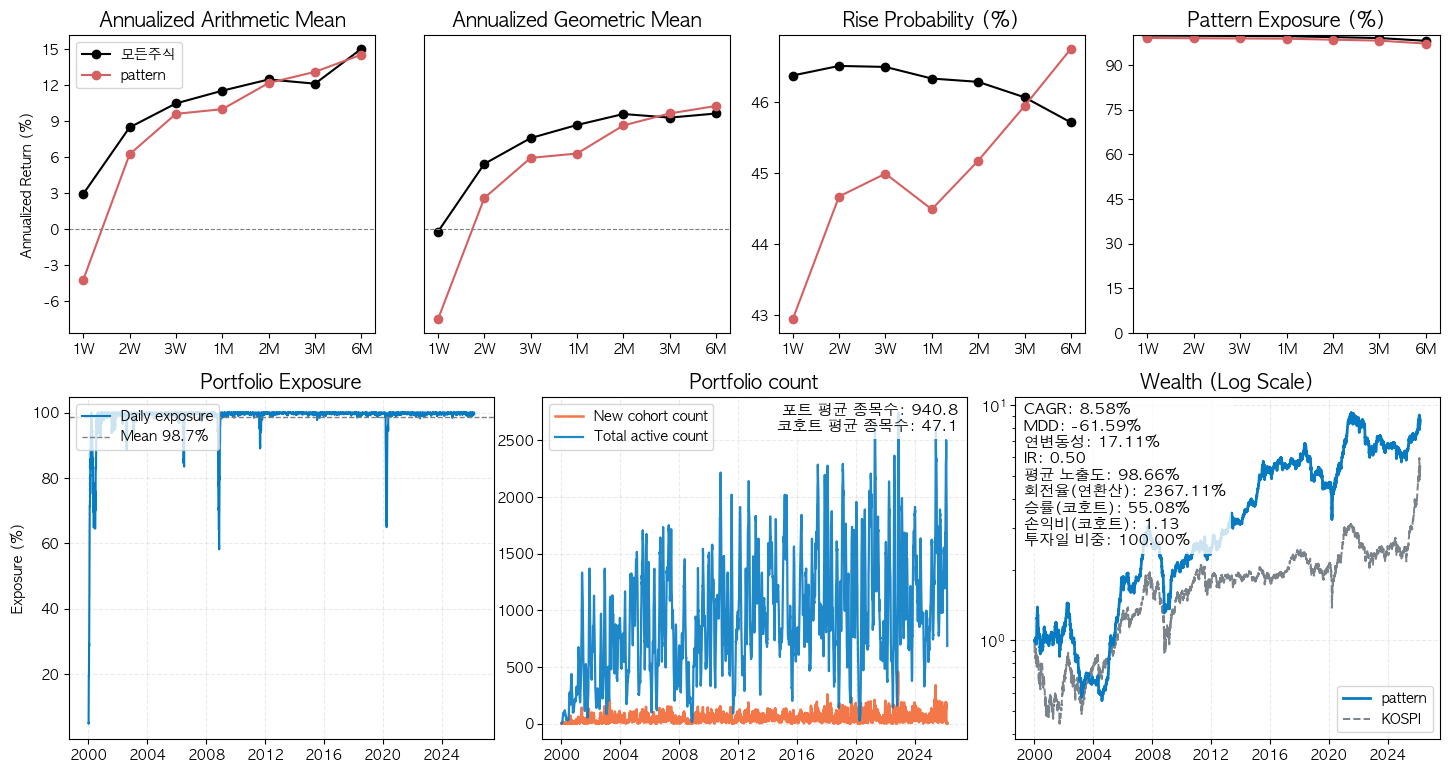

In [5]:
strat = bb.named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 상승추세
* 상승추세 = 200일 이평선이 전일대비 상승

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 25136.47it/s]
pattern | run: 100%|██████████| 6460/6460 [00:04<00:00, 1311.70it/s]


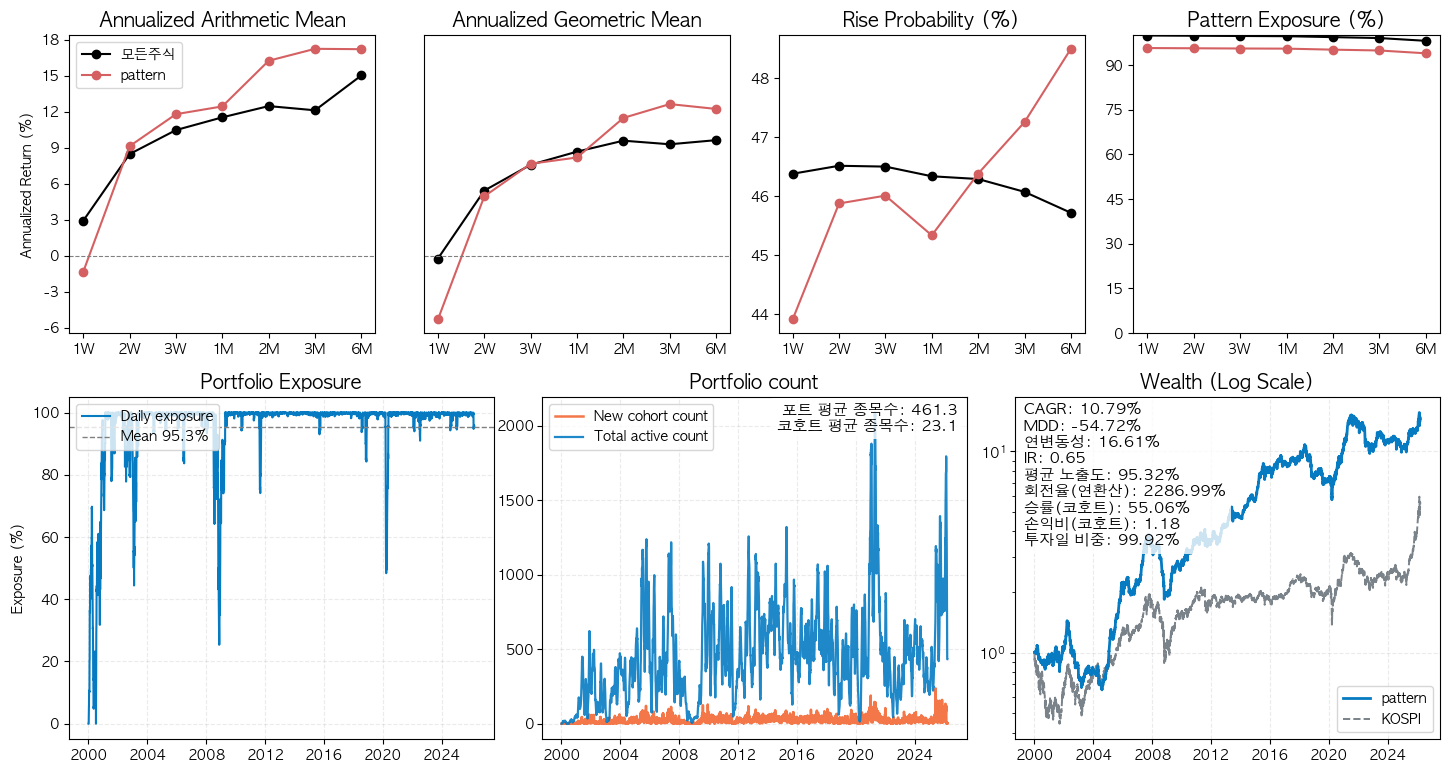

In [19]:
strat = (bb + uptrend).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 52주 고가 근접
* 52주 고가의 90% 수준 내로 진입

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 28086.79it/s]
pattern | run: 100%|██████████| 6460/6460 [00:04<00:00, 1413.48it/s]


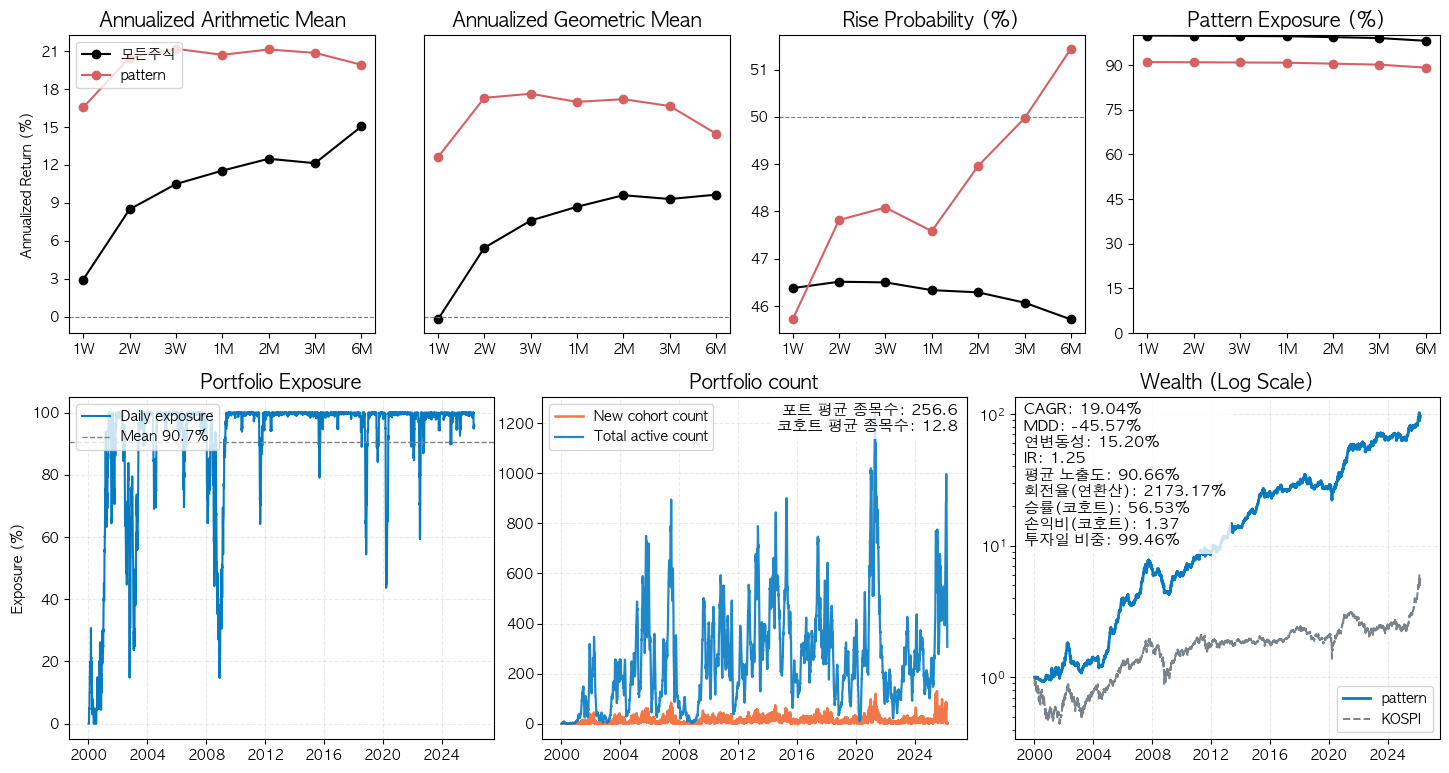

In [20]:
strat = (bb + uptrend + high52w).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) MFI 매수우위
* MFI = 가격과 거래량을 동시에 고려하여 매수/매도 압력 측정 > 50

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 30004.39it/s]
pattern | run: 100%|██████████| 6460/6460 [00:04<00:00, 1415.58it/s]


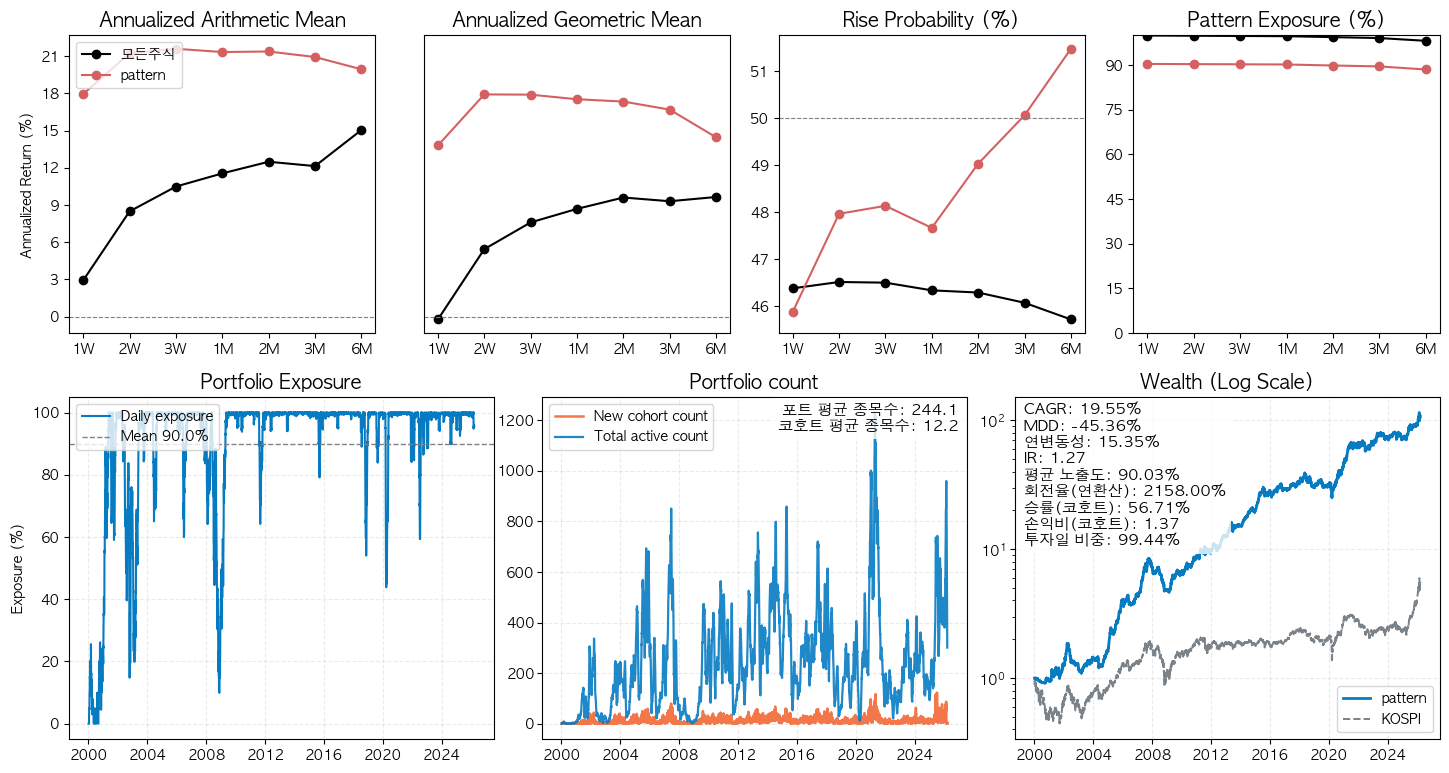

In [21]:
strat = (bb + uptrend + high52w + mfi_high).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 거래량 급증
* 20일 평균거래량에서 50% 이상 급증

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 32331.01it/s]
pattern | run: 100%|██████████| 6460/6460 [00:04<00:00, 1475.49it/s]


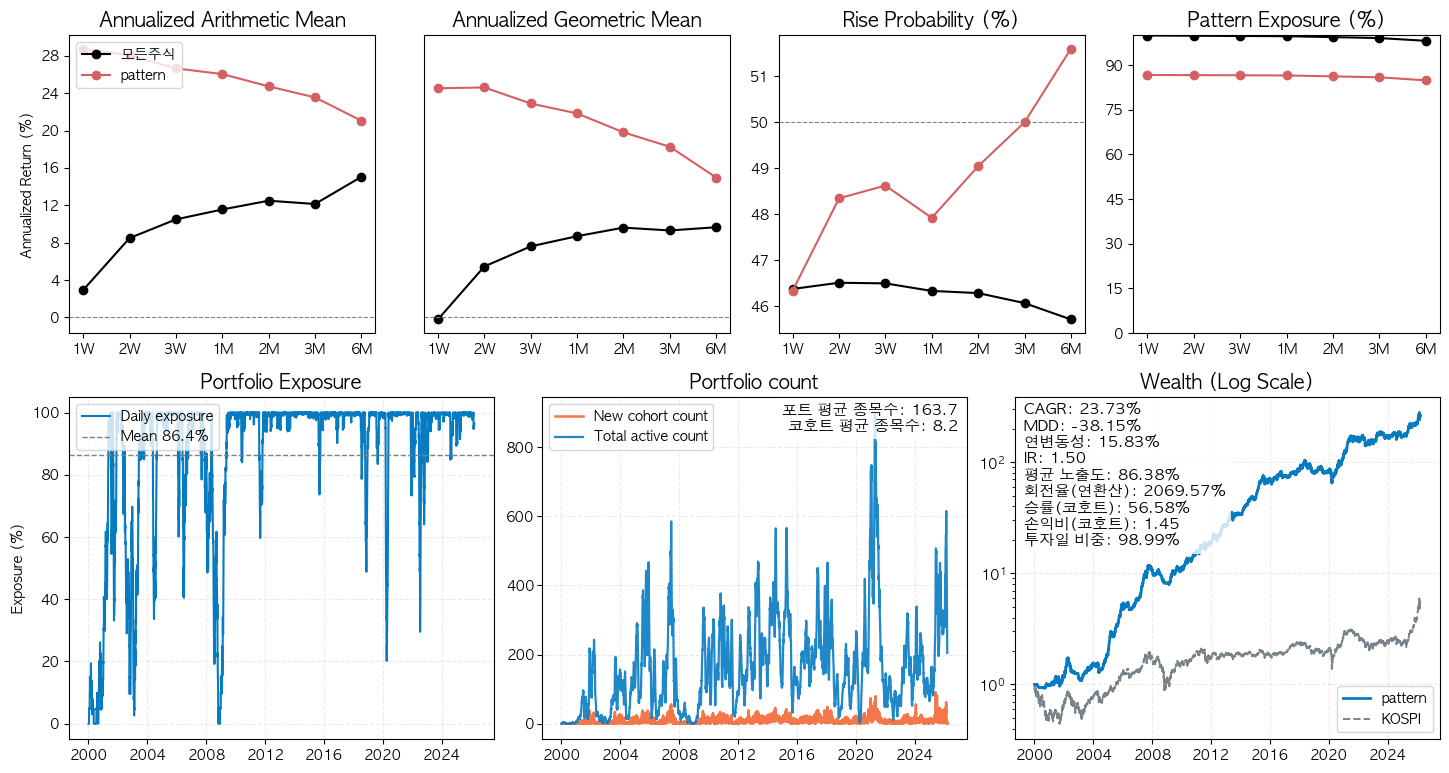

In [22]:
strat = (bb + uptrend + high52w + mfi_high + amt).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 패턴의 특성 강화
* [볼린저밴드] 돌파의 선명성 강화(3일내 최초 돌파) + 폭 축소(5%)
* [거래량] 20일 평균거래량에서 100% 이상 급증

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 39159.00it/s]
pattern | run: 100%|██████████| 6460/6460 [00:02<00:00, 2232.29it/s]


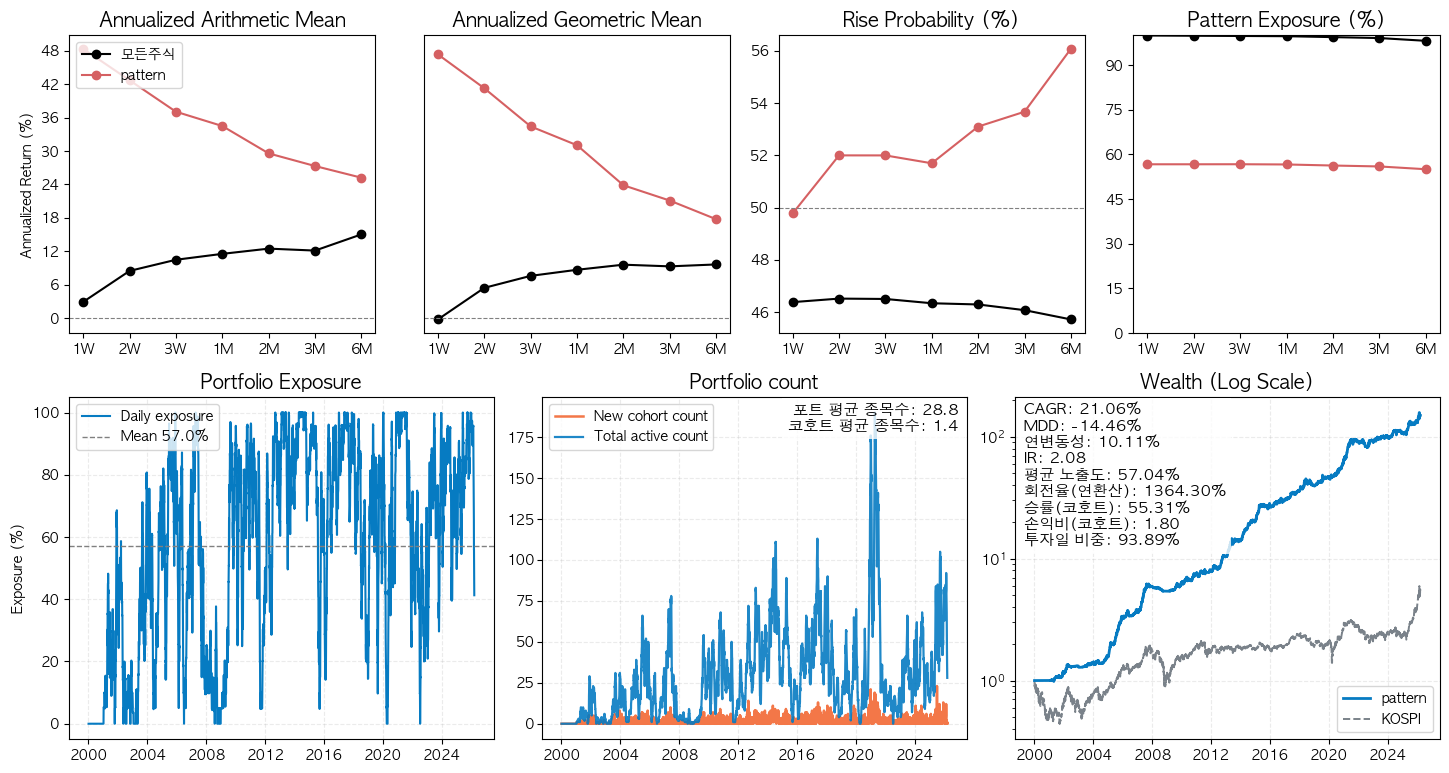

In [23]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 코호트 편입종목 통제
* 각 코호트의 종목수 <= 5개
* 선호기준
    -  시가총액이 클수록
    - 볼린저밴드의 폭이 좁을 수록
    - 거래량 증가의 정도가 클수록
    - 52주 고가의 근접도가 클수록
    - 추세의 강도(기울기)가 클수록
    - MFI가 클수록

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 38962.34it/s]
pattern | run: 100%|██████████| 6460/6460 [00:02<00:00, 2310.33it/s]


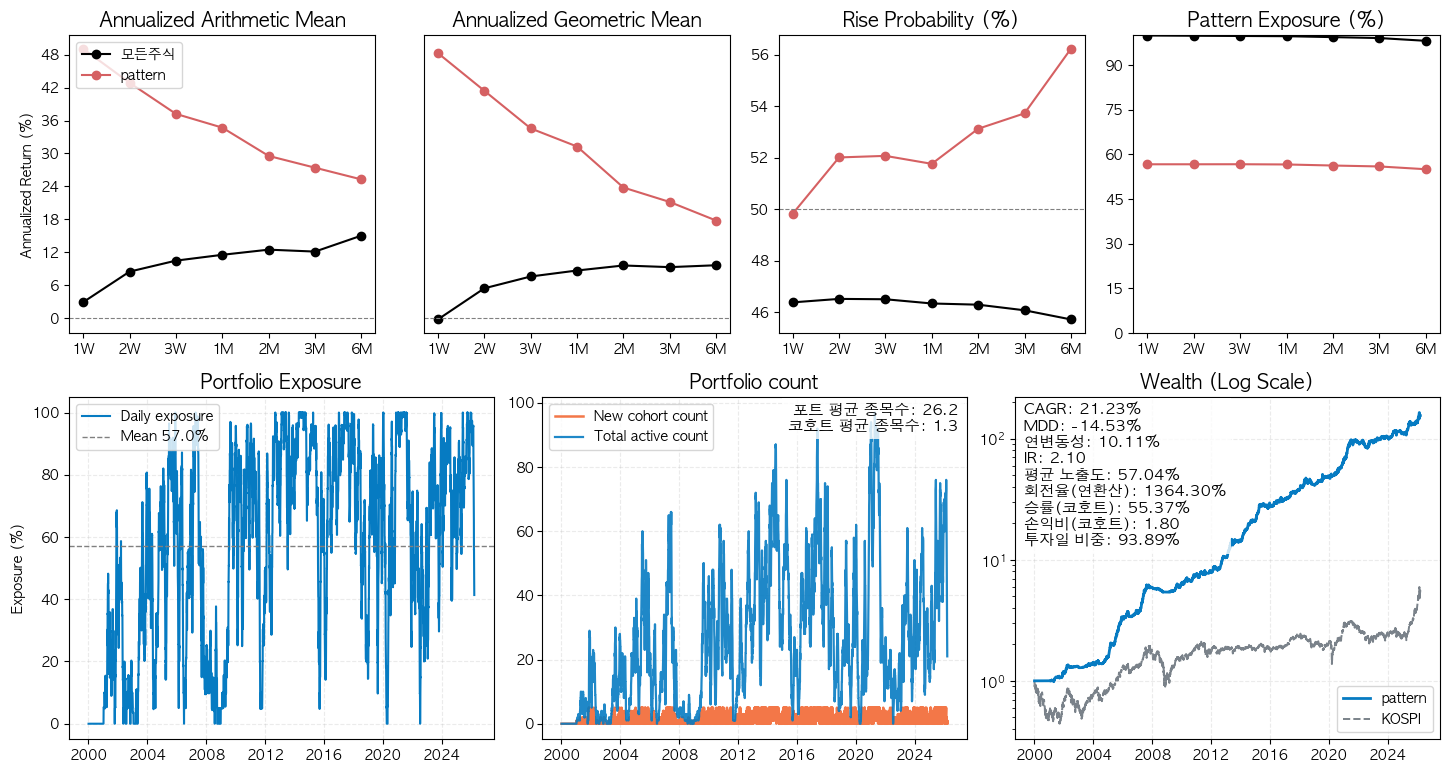

In [24]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 익일종가로 매매
* 종가기준 패턴 확인 후, 종가로 매매하는 것은 비현실적 → 익일종가 매매

pattern | day: 100%|██████████| 6461/6461 [00:00<00:00, 41459.72it/s]
pattern | run: 100%|██████████| 6460/6460 [00:02<00:00, 2551.06it/s]


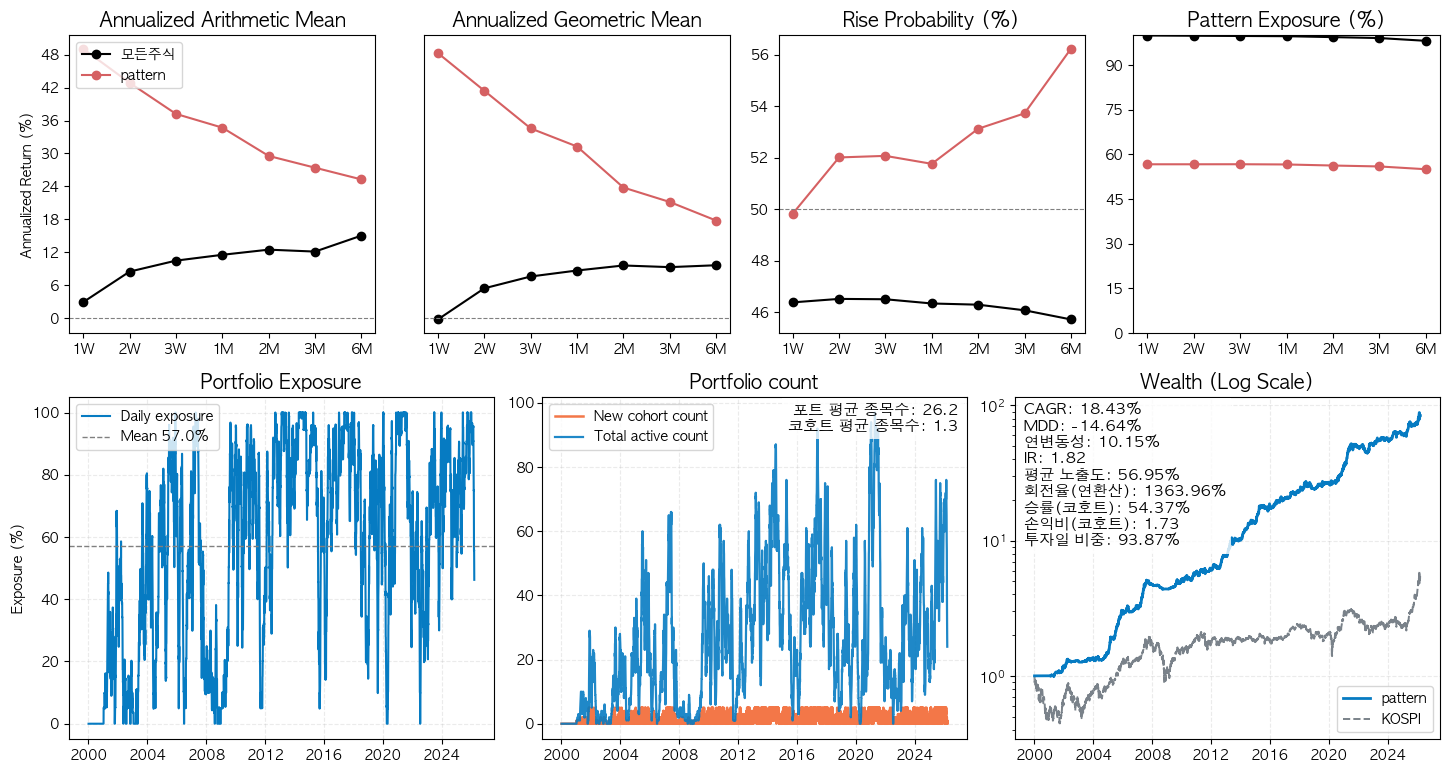

In [7]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)

### 신호조회
* asof 기준으로 패턴출현한 종목 리스트

In [12]:
asof = '2026-03-20'
bt.screen(asof, strat)

,name,close
code,,


### 실제보유 조회
* asof 기준으로 포트폴리오 실제보유 종목 리스트
* trade_price_mode(당일,익일)가 영향을 줌

In [13]:
bt.simulator.port_at(asof)

code      name     value  entry_value  \
cohort_id entry_date age                                            
3661      2026-02-20 19   023900      풍국주정  1.506772     1.459060   
                     19   012280      영화금속  1.463293     1.459060   
                     19   000020      동화약품  1.335635     1.459060   
3662      2026-02-23 18   024740      한일단조  1.055285     0.882887   
                     18   017390      서울가스  0.872724     0.882887   
                     18   210980     SK디앤디  0.867237     0.882887   
                     18   017250       인터엠  0.836503     0.882887   
                     18   096775  SK이노베이션우  0.822479     0.882887   
3663      2026-02-24 17   009140      경인전자  0.911831     0.883959   
                     17   054040     한국컴퓨터  0.846007     0.883959   
                     17   005990     매일홀딩스  0.822053     0.883959   
                     17   330350     위더스제약  0.819514     0.883959   
                     17   208140       정다운  0.799240     0.883959   
3664      2026-02-25 16   017900       광전자  1.512680     1.477171   
                     16   002620   제일파마홀딩스  1.482167     1.477171   
                     16   120240      대정화금  1.475030     1.477171   
3665      2026-02-26 15   024120    KB오토시스  1.421765     1.453056   
                     15   314140     알피바이오  1.318551     1.453056   
                     15   013310      아진산업  1.314765     1.453056   
3666      2026-03-03 13   067920       이글루  4.608004     4.262404   
3667      2026-03-10 8    025880     케이씨피드  2.155905     2.066522   
                     8    023900      풍국주정  2.100857     2.066522   
3668      2026-03-17 3    044780     에이치케이  4.388855     4.199680   
3669      2026-03-20 0    053620        태양  4.210363     4.210363   

                          cohort_value  weight_in_cohort  
cohort_id entry_date age                                  
3661      2026-02-20 19       4.305701          0.349948  
                     19       4.305701          0.339850  
                     19       4.305701          0.310202  
3662      2026-02-23 18       4.454228          0.236918  
                     18       4.454228          0.195932  
                     18       4.454228          0.194700  
                     18       4.454228          0.187800  
                     18       4.454228          0.184651  
3663      2026-02-24 17       4.198645          0.217173  
                     17       4.198645          0.201495  
                     17       4.198645          0.195790  
                     17       4.198645          0.195185  
                     17       4.198645          0.190357  
3664      2026-02-25 16       4.469878          0.338416  
                     16       4.469878          0.331590  
                     16       4.469878          0.329993  
3665      2026-02-26 15       4.055081          0.350613  
                     15       4.055081          0.325160  
                     15       4.055081          0.324227  
3666      2026-03-03 13       4.608004          1.000000  
3667      2026-03-10 8        4.256762          0.506466  
                     8        4.256762          0.493534  
3668      2026-03-17 3        4.388855          1.000000  
3669      2026-03-20 0        4.210363          1.000000

# (번외) 코호트 10일 보유 + 코호트 종목수 10개 이내

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 44624.23it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 4116.32it/s] 


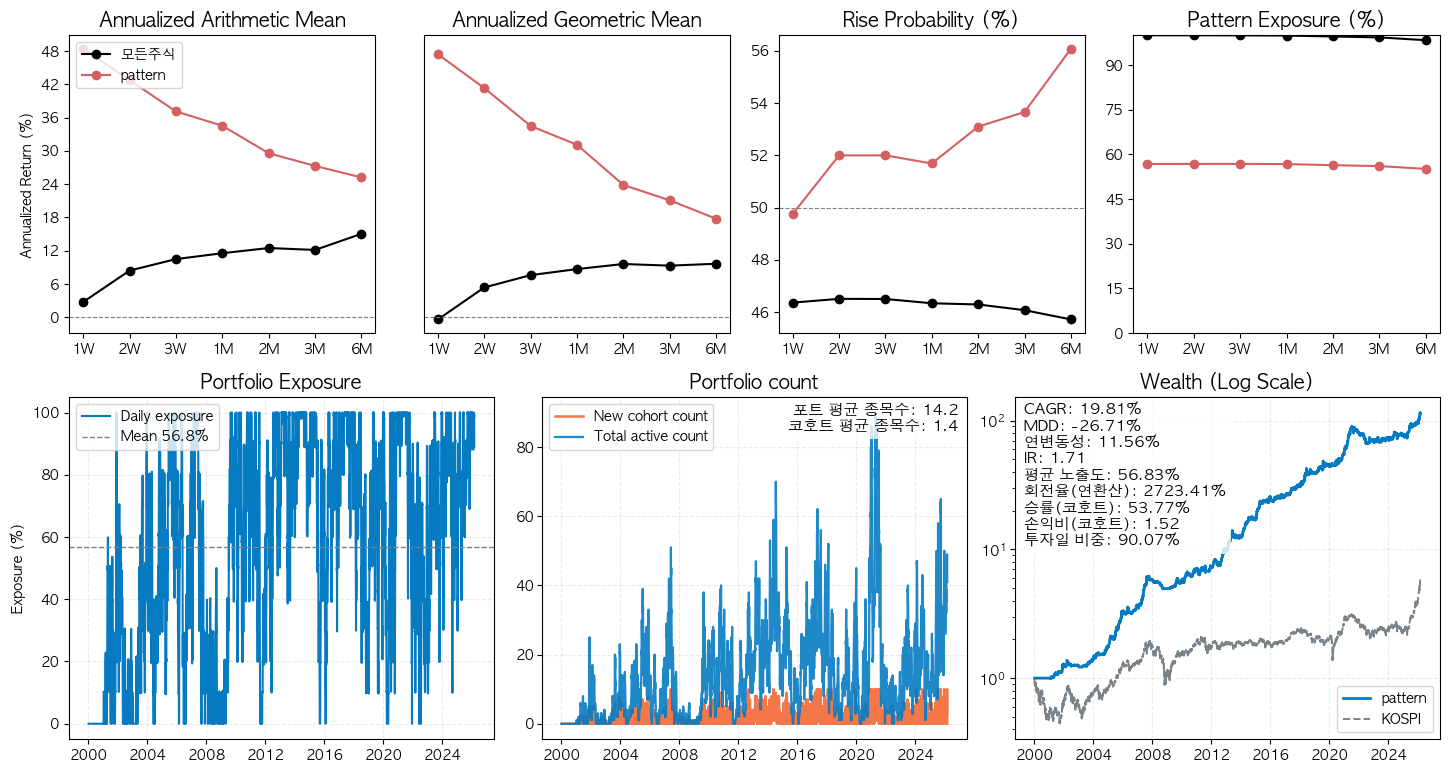

In [13]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(10)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=10, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)

# (번외) 시가총액 1천억 이상으로 제한
* 패턴 출현빈도가 낮아서, 패턴조건은 다소 완화

실행필터 준비 | 필터 마스크: 100%|██████████| 2/2 [00:04<00:00,  2.41s/it]  
pattern: 100%|██████████| 6448/6448 [00:03<00:00, 1795.18it/s]       
pattern | run: 100%|██████████| 6446/6446 [00:02<00:00, 2211.48it/s]


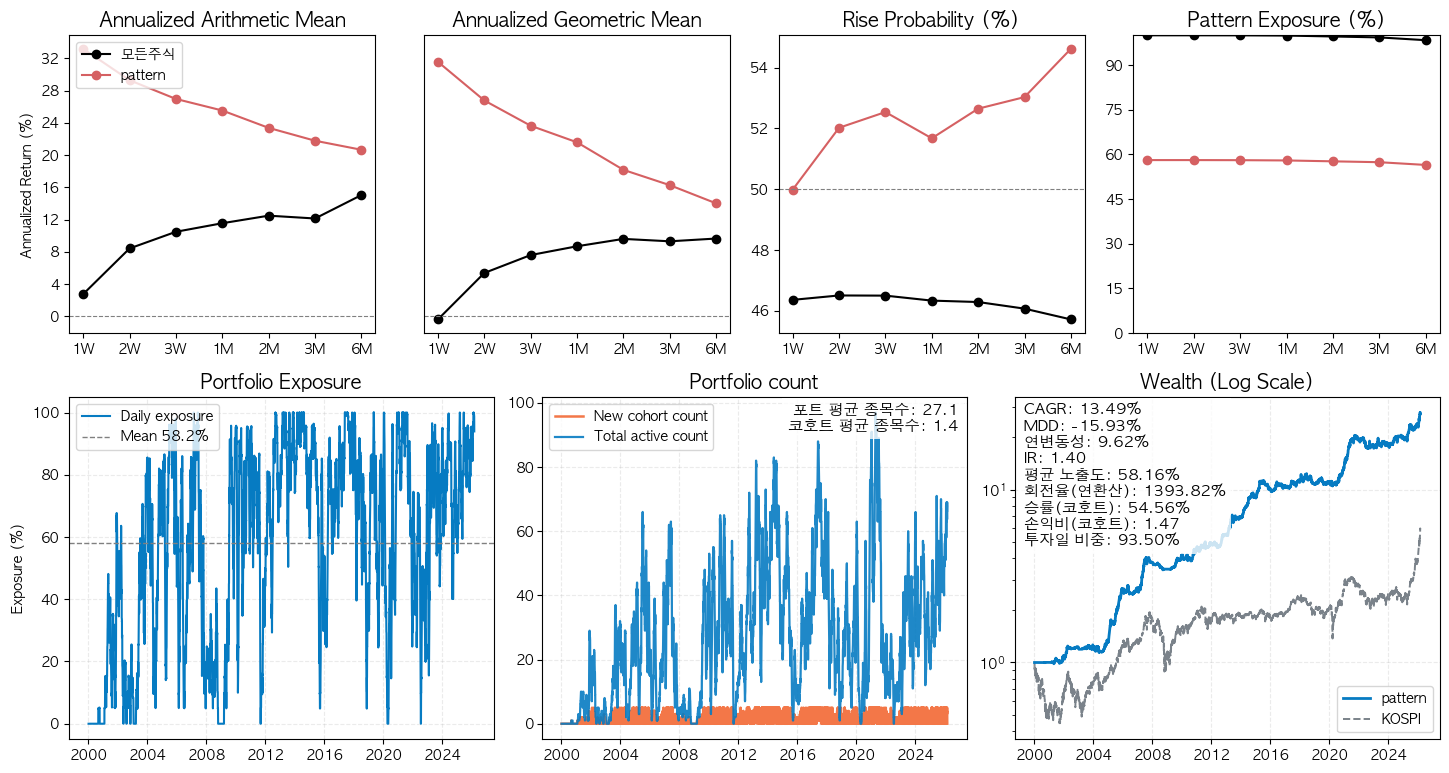

In [14]:
strat = (bb2 + uptrend + high52w + mfi_high + amt).named('pattern')
strat = strat.rank_by(
    # ('stock', 'marketcap.desc'),
    (amt, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat, filter=Filter(market_cap=[5,6,7,8,9,10]))
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)